# Практическое задание

## ЗАДАНИЕ 1: Базовые графики matplotlib

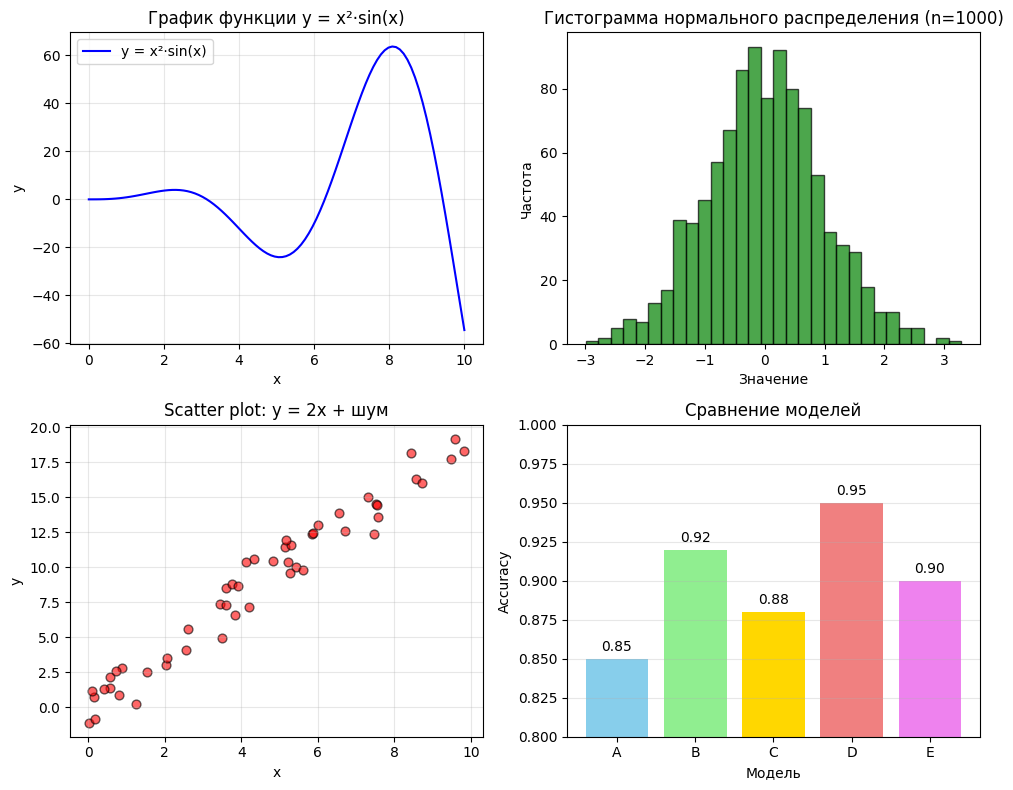

In [ ]:
# Создайте фигуру с 4 subplots (2x2):
# 1. Линейный график функции y = x^2 * sin(x) на интервале [0, 10]
#    Добавьте заголовок, подписи осей, сетку, легенду
# 2. Гистограмма 1000 случайных точек из нормального распределения
#    Настройте количество bins=30, добавьте заголовок
# 3. Scatter plot: 50 точек (x - равномерное распределение, y = 2x + шум)
#    Настройте размер точек, прозрачность, цвет
# 4. Bar chart: сравнение 5 разных моделей по точности
#    accuracy = [0.85, 0.92, 0.88, 0.95, 0.90]
#    Добавьте значения над столбцами

import numpy as np
import matplotlib.pyplot as plt

# Создаем фигуру с 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1. Линейный график y = x^2 * sin(x)
ax = axes[0, 0]
x = np.linspace(0, 10, 100)
y = x**2 * np.sin(x)
ax.plot(x, y, label='y = x²·sin(x)', color='blue')
ax.set_title('График функции y = x²·sin(x)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)
ax.legend()

# 2. Гистограмма нормального распределения
ax = axes[0, 1]
data = np.random.normal(0, 1, 1000)
ax.hist(data, bins=30, color='green', alpha=0.7, edgecolor='black')
ax.set_title('Гистограмма нормального распределения (n=1000)')
ax.set_xlabel('Значение')
ax.set_ylabel('Частота')

# 3. Scatter plot: y = 2x + шум
ax = axes[1, 0]
x = np.random.uniform(0, 10, 50)
y = 2 * x + np.random.normal(0, 1, 50)
ax.scatter(x, y, s=40, alpha=0.6, color='red', edgecolor='black')
ax.set_title('Scatter plot: y = 2x + шум')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)


# 4. Bar chart: точность моделей
ax = axes[1, 1]
models = ['A', 'B', 'C', 'D', 'E']
accuracy = [0.85, 0.92, 0.88, 0.95, 0.90]
bars = ax.bar(models, accuracy, color=['skyblue', 'lightgreen', 'gold', 'lightcoral', 'violet'])
ax.set_title('Сравнение моделей')
ax.set_xlabel('Модель')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.800, 1.0)
ax.grid(True, axis='y', alpha=0.3)

# Добавляем значения над столбцами
for bar, acc in zip(bars, accuracy):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{acc:.2f}', ha='center')

plt.tight_layout()
plt.show()


## ЗАДАНИЕ 2: Seaborn визуализации

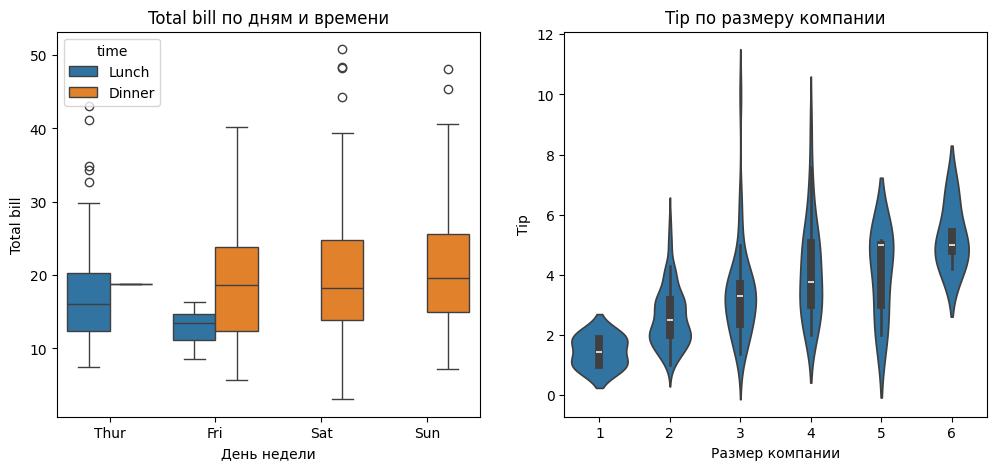

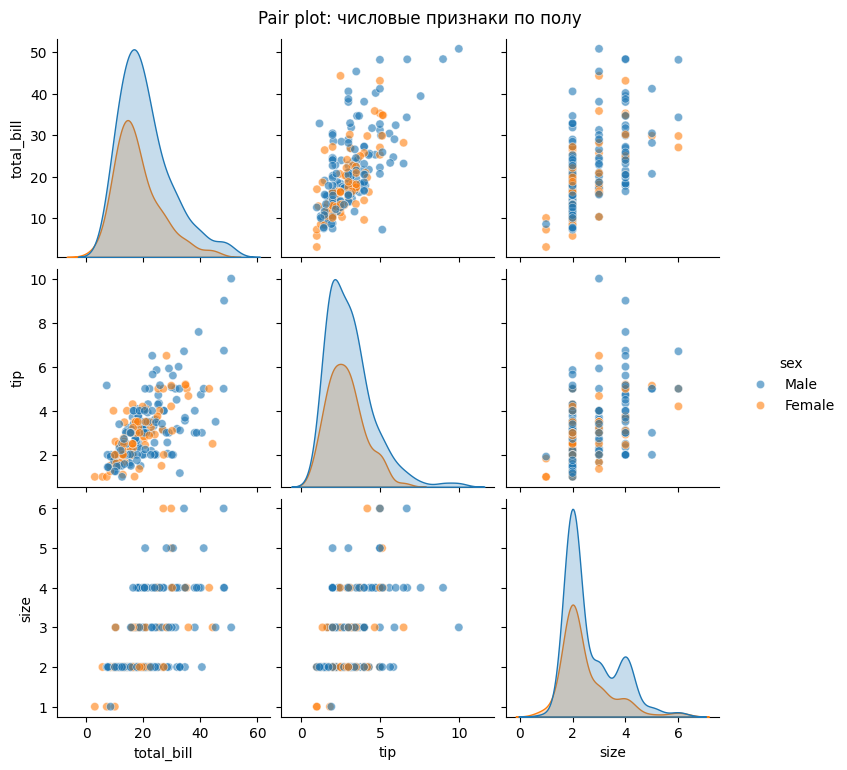

In [2]:
# Используйте датасет tips из seaborn:
# import seaborn as sns
# tips = sns.load_dataset('tips')

# Создайте 3 графика:
# 1. Box plot: total_bill по дням недели (day)
#    Разделите дополнительно по времени (time) с помощью hue
# 2. Violin plot: tip в зависимости от размера компании (size)
# 3. Pair plot: выберите 4 числовых признака, раскрасьте по полу (sex)

import seaborn as sns
import matplotlib.pyplot as plt

# Загружаем датасет
tips = sns.load_dataset('tips')

# Создаем фигуру для графиков
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Box plot: total_bill по дням с разделением по времени
# data=tips, x='day', y='total_bill', hue='time'
sns.boxplot(data=tips, x='day', y='total_bill', hue='time', ax=axes[0])
axes[0].set_title('Total bill по дням и времени')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Total bill')

# 2. Violin plot: tip по размеру компании
# x='size', y='tip'
sns.violinplot(data=tips, x='size', y='tip', ax=axes[1])
axes[1].set_title('Tip по размеру компании')
axes[1].set_xlabel('Размер компании')
axes[1].set_ylabel('Tip')

# 3. Pair plot: 4 числовых признака, раскраска по полу
# tips[['total_bill', 'tip', 'size', 'sex']]
# Создаем отдельную фигуру для pair plot
pair_plot = sns.pairplot(tips[['total_bill', 'tip', 'size', 'sex']],
                        hue='sex',
                        diag_kind='kde',
                        plot_kws={'alpha': 0.6})
pair_plot.fig.suptitle('Pair plot: числовые признаки по полу', y=1.02)
plt.show()